## **BMW Used Cars Price Prediction**

**INTRODUCTION**

Used car cost prediction is a important issue in the automotive sector, where vehicle values differ depending on the variables like engine, age, mileage and shade color. with incraesing accessibility of online cars listings, traditional costing approaches are frequently insufficient to reprent complicated  market trends. To tackle this problem ML methods are broadly used to identify hidden connections within the the dataset and provide precise value prediction. An End to end Machine learning pipeline is created to preprocess the data fit several algorithms and assess their performance for dependable value prediction.

**BUSINESS PROBLEM**

The used cars market is one of the data abundant and cost sensitive secorts of the automotive industry. In contrast to new cars, vehicle have values that rely on a complicated interaction of variables like age, engine power fuel type and  vendor behavior making precise pricing both challenging and highly beneficial.Inaccurate pricing can result in major business problems including decreased profit when cars are priced too low or extended stock retention when they are priced too high.

Importance of this problem:

* Revenue Optimization: Precise costing directly enhances the earnings margins

* Inventory Management: Quicker rotation when cars are valued competively

*  Customer Trust: Clear data driven values boost buyer trust

* Competitive Intelligence: Understanding which features influence value enables better buying choices at auction.



**ML FORMULATION**

This is a supervised regression task the taget variable is continuous selling value of a BMW and the features are cars attributes. The algorithm will identify a function from labeled historical entries and perfomance will evaluated using regression matrics like RMSE, R²and MAE. To show the flexibility of method i additionally defined a classification variant by dividing BMW cars into value categories based on thier salling value. Classification performance will be evaluated using metrics such a sthe confusion matrix and ROC curve.

**DATA SET LINK**

https://www.kaggle.com/datasets/danielkyrka/bmw-pricing-challenge

**IMPORTING LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

**LOADING DATASET**

In [ ]:
df = pd.read_csv("/content/BMW_Pricing_new_Dataset")

In [ ]:
df.head()

,maker_key,model_key,mileage,engine_power,registration_date,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price,sold_at
0,NaN,NaN,140411.0,100.0,2012-02-01,diesel,black,convertible,True,True,False,False,True,True,True,False,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,NaN,True,False,False,False,True,NaN,True,69700.0,2018-02-01
2,BMW,NaN,183297.0,120.0,2012-04-01,diesel,white,convertible,False,False,False,False,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,2014-07-01,diesel,red,convertible,True,True,False,False,True,True,True,True,25100.0,NaN
4,BMW,425,97097.0,160.0,2014-12-01,diesel,silver,convertible,True,True,NaN,False,False,True,True,True,33400.0,2018-04-01


In [ ]:
df.shape

(4843, 18)

**EXPLORATORY DATA ANALYSIS (EDA)**

**Checking For Missing Values**

Why its neccessary?

Identifying missing values is crucial as they can impact model training , indroduce bias and decrease predict accuracy therefore addressing them correctly ensures reliable ML outcomes.

In [ ]:
df.isnull().sum()

,0
maker_key,431
model_key,434
mileage,444
engine_power,460
registration_date,416
fuel,433
paint_color,400
car_type,417
feature_1,413
feature_2,435


**DATA CLEANING**

**Remove all the missing and null values**

In [ ]:
before = len(df)
df = df.dropna(subset=['price'])
after = len(df)
print(f"Rows dropped due to missing price: {before - after}")
print(f"Remaining rows: {after:,}")

Rows dropped due to missing price: 419
Remaining rows: 4,424


Why?

The target variable is essential any rows missing the price label is entirely unusuable for supervised learning and must be eliminated before to any further cleaning

In [ ]:
threshold = 0.50
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 18


Why?

A column with over 50% missing data has weak predictive signal to be accurately filled. keeping it would add more noise than information into the algorithm

In [ ]:
remaining_nulls = df.isnull().sum().sum()
print(f"Total remaining null values: {remaining_nulls}")

if remaining_nulls == 0:
    print(" No missing values .")
else:
    print("Warning")

print(f"\nFinal shape: {df.shape}")

Total remaining null values: 6583
Warning

Final shape: (4424, 18)


**Target Variable - Price Distribution**

The following code visualise the distribution of the target variable Price showing both orginal value and log transformed version to highlight the skewness.

* Identifies the skewness within the target variable
* Lowers the skewness and stabilizes variance for better model accuracy
*  Helps in detecting outliers that could influence prediction

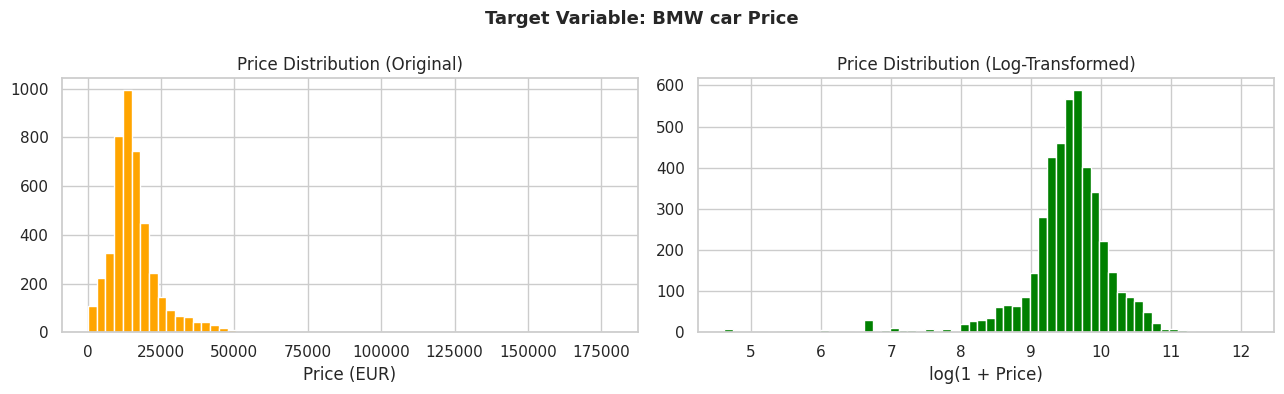

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['price'], bins=60,color='orange', edgecolor='white')
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (EUR)')
axes[1].hist(np.log1p(df['price']), bins=60, color='Green', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(1 + Price)')
plt.suptitle('Target Variable: BMW car Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**
* Originalvalue histogram - right skewed
* Logtransformed histogram - approximately symmetric

**Categorical Feature Analysis**

The code creates a boxplot to display how BMW car sales price differ amaong the fuel categories arranging the fuel groups in order of median value. this helps to undertsnd the relation between a categorical and target variable, identify the pattern or outliers and give insignts which can direct feature selection and engineering for ML model.

/tmp/ipykernel_1462/2276610668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fuel', y='price', order=order, ax=ax, palette='Set2')


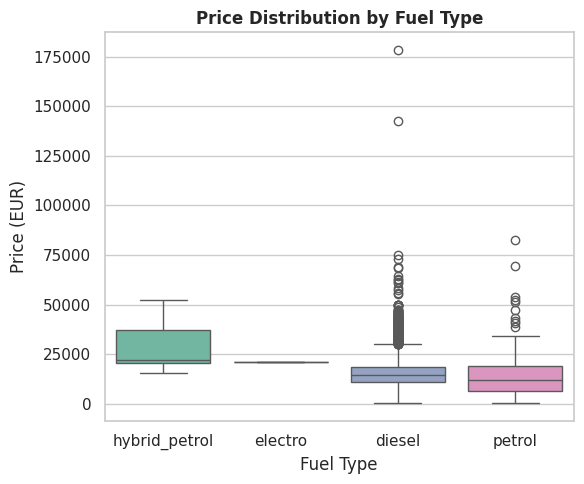

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'fuel' in df.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    order = df.groupby('fuel')['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='fuel', y='price', order=order, ax=ax, palette='Set2')
    ax.set_title('Price Distribution by Fuel Type', fontweight='bold')
    ax.set_xlabel('Fuel Type')
    ax.set_ylabel('Price (EUR)')
    plt.tight_layout()
    plt.show()

**Numerical Feature Analysis**

The following code generates scatter plots to visualise the relationship between BMW car sale price and important numrical features such as mileage, age and engine power. By charting every features against the target variable it helps to detect the pattern correlations or patterns which could effect pricing.

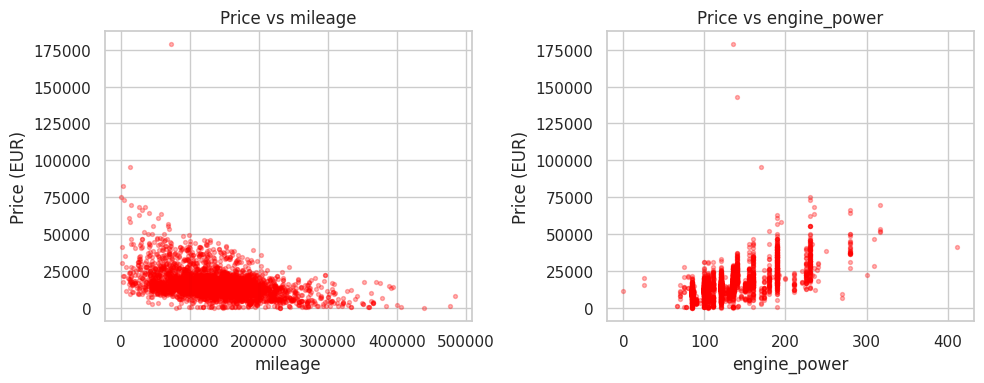

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_feats = [c for c in num_cols if c != 'price']
key_feats = [c for c in ['mileage', 'engine_power', 'age_car'] if c in df.columns]
if key_feats:
    fig, axes = plt.subplots(1, len(key_feats), figsize=(5 * len(key_feats), 4))
    if len(key_feats) == 1:
        axes = [axes]
    for ax, feat in zip(axes, key_feats):
        ax.scatter(df[feat], df['price'], alpha=0.3, s=8, color='Red')
        ax.set_xlabel(feat)
        ax.set_ylabel('Price (EUR)')
        ax.set_title(f'Price vs {feat}')
        plt.tight_layout()
    plt.show()

**CORELATION HEATMAP**

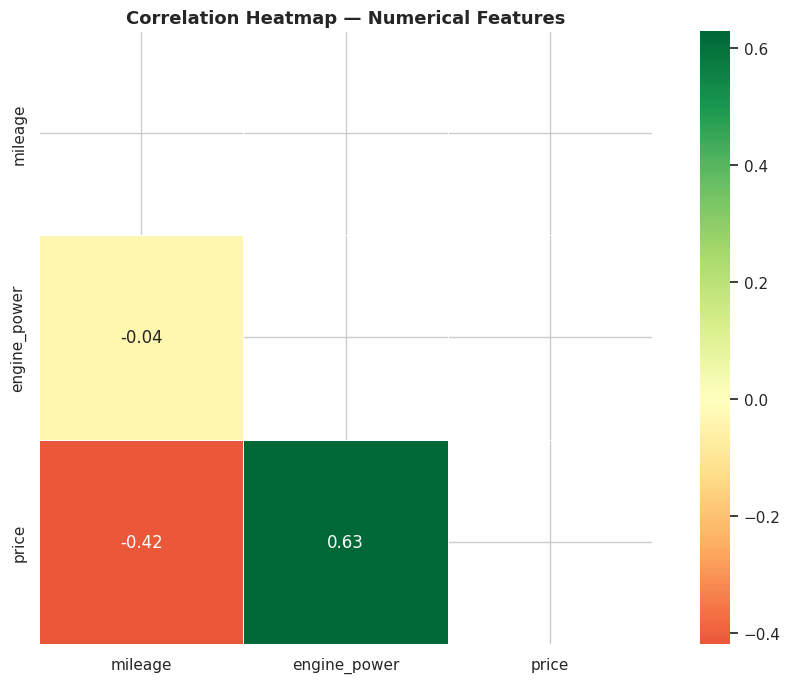

Correlation with price (sorted):
engine_power    0.628806
mileage        -0.417842
Name: price, dtype: float64


In [ ]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with price (sorted):')
print(corr['price'].drop('price').sort_values(ascending=False))

**Insights**
* As the dataset has less numerical features the correlation heatmap is limited to the given columns making it easy to understand the relationship with price
* Higly positive correlation: Engine power indicates high postive correlation with price showing more powerful cars are more costly
* Medium Negative Correlation: car age usually have a medium negative correlation with value implying earlier model cars are typically less expensive   
* Mileage Impact: Mileage shows a negative correlation with price indicating which cars have greater mileage genrally cost less

**OUTLIER DETECTION**

Following code creates boxplots for every features of numerical columns showing showing the distribution median quartiles and potential outliers for each feature. It provides quick visualization of the range and outliers of the dataset assisting in detecting unusual values and understand variable patterns which can inform data preprocessing procedures like outlier treatment or transformation prior to developing ML algorithms

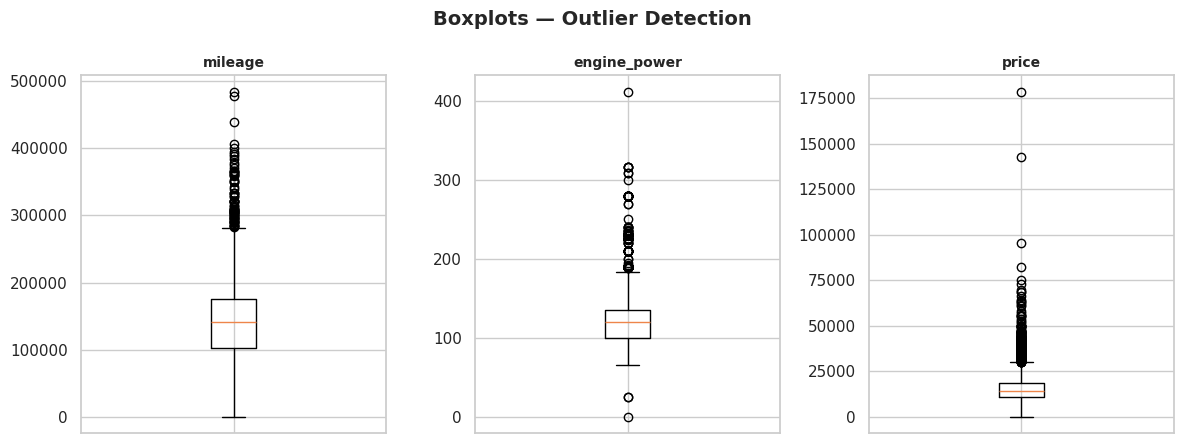

In [ ]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4.5))
if len(num_cols) == 1:
  axes = [axes]
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticklabels([])
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights**

* **Outlier Detected** - Specific features such as mileage or engine power display extreme values which might require capping or adjustment.

* **Skewed Distributions** - Certain features are not evenly spread which could influence ML model effectiveness

* **Feature Spread** - Assists understand which variables have large variance and may require scaling



**DATA PREPROCESSING AND FEATURE ENGINEERING**

**Outlier Removal and Log Transformation of Target**

This code discards the extreme outliers from the price column by selecting values between 1st and 99th percentiles creating a cleaner dataset.

It then performs a log transformation to minimiise the skewness and make the distribution more suitable for analysis.

Finally it displays how many rows were removed and the skewness of the log transformed price to assess the enhancement.


In [ ]:
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
df_clean = df[(df['price'] >= p01) & (df['price'] <= p99)].copy()
print(f'Rows removed: {len(df) - len(df_clean):,}  |  Remaining: {len(df_clean):,}')
df_clean['log_price'] = np.log1p(df_clean['price'])
print(f'Log-price skewness: {df_clean["log_price"].skew():.3f}')

Rows removed: 66  |  Remaining: 4,358
Log-price skewness: -1.581


**FEATURE ENGINEERING**

* Computes car age_year using first registration to indicate cars age

* Calculates mileage_per_year by splitting total distance by age to evaluate vehicle usage instensity

* Computes power_per_year to connect engine power with car age indicating perfomance over time

In [ ]:
if 'registration_date' in df_clean.columns:
    df_clean['registration_date'] = pd.to_datetime(df_clean['registration_date'], errors='coerce')
    df_clean['age_years'] = (
        (pd.Timestamp('2020-06-01') - df_clean['registration_date']).dt.days / 365.25
    )

if 'mileage' in df_clean.columns and 'age_years' in df_clean.columns:
    df_clean['mileage_per_year'] = (
        df_clean['mileage'] / df_clean['age_years'].replace(0, np.nan)
    ).fillna(df_clean['mileage'].median())
if 'engine_power' in df_clean.columns and 'age_years' in df_clean.columns:
    df_clean['power_per_year'] = df_clean['engine_power'] / (df_clean['age_years'] + 1)
print(f'\nDataset shape after feature engineering: {df_clean.shape}')


Dataset shape after feature engineering: (4358, 22)


**Price Tiers for Classification**

To illustarate classification matrics together with regression, price is categorized into 3 tiers representing actual dealership inventory segments


Price tier distribution:
  Budget         858  (19.7%)
  Mid-range     3078  (70.6%)
  Premium        422  (9.7%)


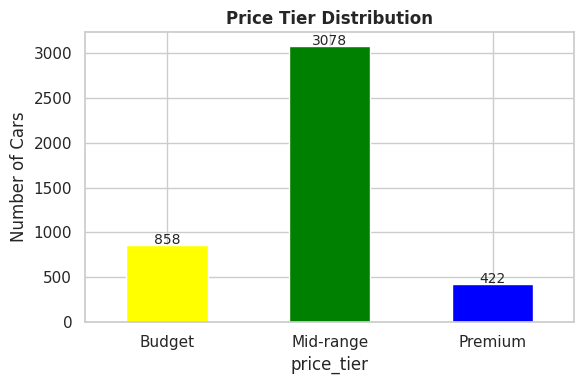

In [ ]:
BINS   = [0, 10_000, 25_000, np.inf]
LABELS = ['Budget', 'Mid-range', 'Premium']

df_clean['price_tier'] = pd.cut(df_clean['price'], bins=BINS, labels=LABELS)

print('Price tier distribution:')
counts = df_clean['price_tier'].value_counts().sort_index()
for tier, count in counts.items():
    print(f'  {tier:<12} {count:>5}  ({100*count/len(df_clean):.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax,
            color=['yellow', 'green', 'blue'], edgecolor='white', rot=0)
ax.set_title('Price Tier Distribution', fontweight='bold')
ax.set_ylabel('Number of Cars')
for bar, val in zip(ax.patches, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insights**

* The price tier breakdown shows which categories lead the inventory highlighting typical price ranges
* The visualisation offers a clear comparision of the number of cars in every tier
* Establishing these tiers allow the dataset to handle classification task supporting regression modeling for price prediction
* Most cars in the dataset belong to mid range tier indicating that dealer inventory is concetrated.

**TRAIN AND TEST SPLIT**

I have split data into,
* Training Set  70% : Utilized to fit all the models
* Validation Set 15% : Used in order to evaluate models  and tune hyperparameters held apart from the testing data for avaaid contaminating the final analysis
* Test Set 15% : Reserved completely and apllied only once for the last objective evaluation of the best model

The split is executed befoer any preprocessing is fit to avoid data leakage

In [ ]:
drop_cols = ['price', 'log_price', 'price_tier']
if 'registration_date' in df_clean.columns:
    drop_cols.append('registration_date')
X = df_clean.drop(columns=drop_cols)
y_reg  = df_clean['log_price']
y_cls  = df_clean['price_tier']
X_tv,    X_test,  y_tv,   y_test  = train_test_split(X, y_reg, test_size=0.15,  random_state=RANDOM_STATE)
X_train, X_val,   y_train, y_val  = train_test_split(X_tv, y_tv, test_size=0.176, random_state=RANDOM_STATE)
X_tr_c, X_te_c, y_tr_c, y_te_c  = train_test_split(X, y_cls, test_size=0.20,
                                                      random_state=RANDOM_STATE, stratify=y_cls)

**PREPROCESSING PIPELINE**


Why each steps?

* Simple Imputer (median): Replaces missing numerical values with median which is insensitive to outliers. mode replacement is used for categorical attributes

* Standard Scaler: normalises numeric attributes to have zero mean and unit variance. this ensures that variables are measured with varying units (km vs. hp) could bias distance based algorithms

* OneHotEncoder: transforms nominal attributes as 0-1 columns , this prevents introducing artificial order on nominal features like paint color or fuel type

In [ ]:
numeric_features     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print('Numeric features:    ', numeric_features)
print('Categorical features:', categorical_features)


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)
X_tr_c_p  = preprocessor.fit_transform(X_tr_c)
X_te_c_p  = preprocessor.transform(X_te_c)
X_tv_p    = np.vstack([X_train_p, X_val_p])
y_tv_comb = pd.concat([y_train, y_val])
print(f'\nPreprocessed feature count: {X_train_p.shape[1]}')

Numeric features:     ['mileage', 'engine_power', 'age_years', 'mileage_per_year', 'power_per_year']
Categorical features: ['maker_key', 'model_key', 'fuel', 'paint_color', 'car_type', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'sold_at']

Preprocessed feature count: 116


**HELPER FUNCTIONS**

I have created the helper functions to measure both classification model and regression model in a standardized manner by centralising this logic every model is evaluated with the same matrics,  visualisation such as scatter plots, confusion matrics , ROC curve and residual plots. this guarantees reproducibility, avoids repeatation of the code and simplifies the comparision of various models.


In [ ]:
def evaluate_regressor(model, X_tr, y_tr, X_va, y_va, X_te, y_te, name):
    model.fit(X_tr, y_tr)

    val_euro  = np.expm1(y_va)
    pred_val  = np.expm1(model.predict(X_va))
    test_euro = np.expm1(y_te)
    pred_test = np.expm1(model.predict(X_te))

    print(f'\n{"="*58}')
    print(f'  REGRESSOR: {name}')
    print(f'{"─"*58}')
    print(f'  Validation  MAE: EUR {mean_absolute_error(val_euro, pred_val):>8,.0f}  '
          f'RMSE: EUR {np.sqrt(mean_squared_error(val_euro, pred_val)):>8,.0f}  '
          f'R2: {r2_score(val_euro, pred_val):.4f}')
    print(f'  Test        MAE: EUR {mean_absolute_error(test_euro, pred_test):>8,.0f}  '
          f'RMSE: EUR {np.sqrt(mean_squared_error(test_euro, pred_test)):>8,.0f}  '
          f'R2: {r2_score(test_euro, pred_test):.4f}')
    print(f'{"="*58}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    mx = max(test_euro.max(), pred_test.max())
    axes[0].scatter(test_euro, pred_test, alpha=0.35, s=12, color='purple')
    axes[0].plot([0, mx], [0, mx], 'b--', lw=1.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual Price (EUR)')
    axes[0].set_ylabel('Predicted Price (EUR)')
    axes[0].set_title(f'{name} — Predicted vs Actual')
    axes[0].legend()

    residuals = test_euro - pred_test
    axes[1].scatter(pred_test, residuals, alpha=0.35, s=12, color='green')
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted Price (EUR)')
    axes[1].set_ylabel('Residual (EUR)')
    axes[1].set_title(f'{name} — Residual Plot')

    plt.tight_layout()
    plt.show()
    return model, r2_score(test_euro, pred_test), mean_absolute_error(test_euro, pred_test), np.sqrt(mean_squared_error(test_euro, pred_test))


def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)

    print(f'\n{"="*58}')
    print(f'  CLASSIFIER: {name}')
    print(f'{"─"*58}')
    print(classification_report(y_te, y_pred, target_names=LABELS))

    cm      = confusion_matrix(y_te, y_pred, labels=LABELS)
    cm_norm = confusion_matrix(y_te, y_pred, labels=LABELS, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(cm,      display_labels=LABELS).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{name}\nConfusion Matrix — Raw Counts', fontweight='bold')
    ConfusionMatrixDisplay(cm_norm, display_labels=LABELS).plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title(f'{name}\nConfusion Matrix — Normalised (Recall per Class)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    y_bin   = label_binarize(y_te, classes=LABELS)
    colors  = ['yellow', 'green', 'blue']
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, (lbl, col) in enumerate(zip(LABELS, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{lbl}  (AUC = {auc:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} — ROC Curve (One-vs-Rest)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()
    return model

**MODEL BUILDING**

**MODEL 1: DECISION TREE**

Following code applies a decision tree regressor on training set estimates predictions for validation and testing data anad calculates performance matrics with plots.

**Purpose**

* Presents a clear visualizable model which is easier to explain to the stakeholders
* Identify  realtionship between variables and non linear trends in the dataset
* Acts as baseline for evaluation against advanced ensemble models


  REGRESSOR: Decision Tree
──────────────────────────────────────────────────────────
  Validation  MAE: EUR    2,842  RMSE: EUR    4,023  R2: 0.7031
  Test        MAE: EUR    2,880  RMSE: EUR    4,090  R2: 0.6644


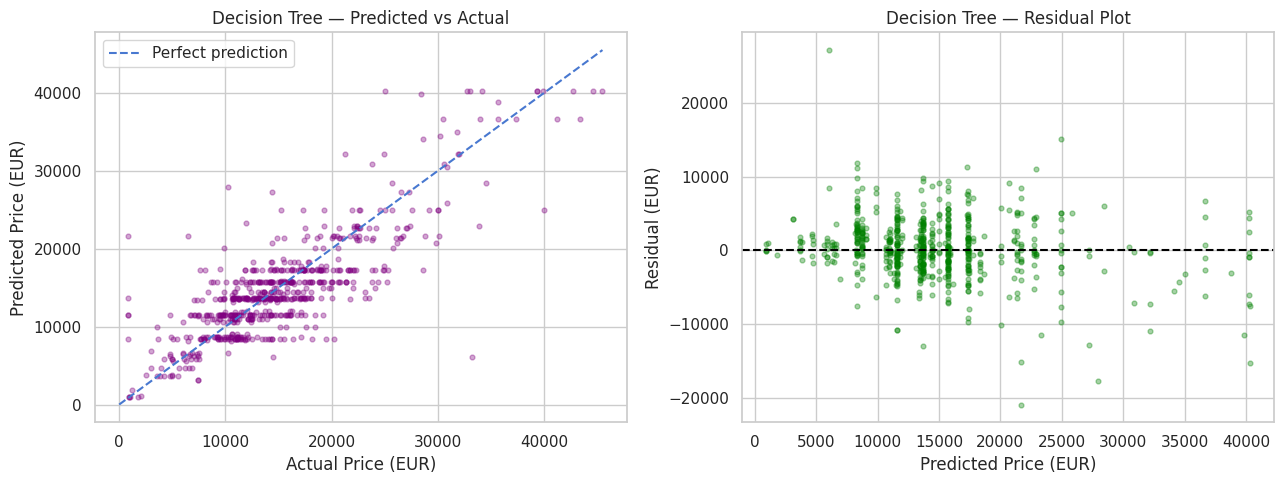

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=RANDOM_STATE)

dt_fitted, dt_r2, dt_mae, dt_rmse = evaluate_regressor(
    dt_reg,
    X_train_p, y_train,
    X_val_p,   y_val,
    X_test_p,  y_test,
    name='Decision Tree'
)

**Insights**

* The decision tree model achives a observable level of efficiency assessed with R2, MAE, and RMSE over validation and testing data

* Comparision among validation and testing metrics assists determine if the model is overfitting or generalising correctly

* The predicted vs actual and residual plots provide a graphical insight of prediction accuracy and error trends

**CONFUSION MATRIX AND ROC CURVE FOR DECISION TREE**



  CLASSIFIER: Decision Tree
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Budget       0.77      0.57      0.66       172
   Mid-range       0.84      0.94      0.89       616
     Premium       0.84      0.56      0.67        84

    accuracy                           0.83       872
   macro avg       0.82      0.69      0.74       872
weighted avg       0.83      0.83      0.82       872



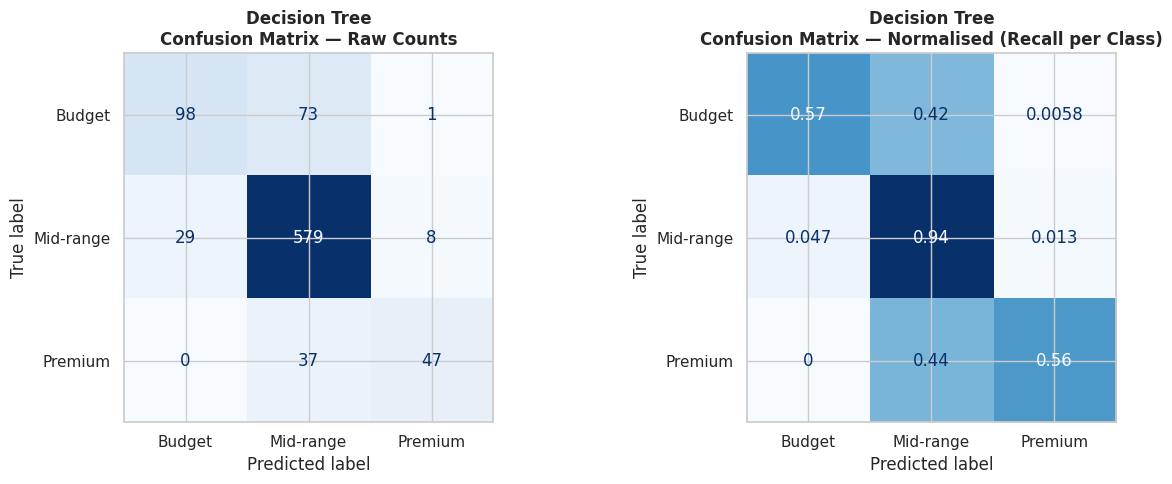

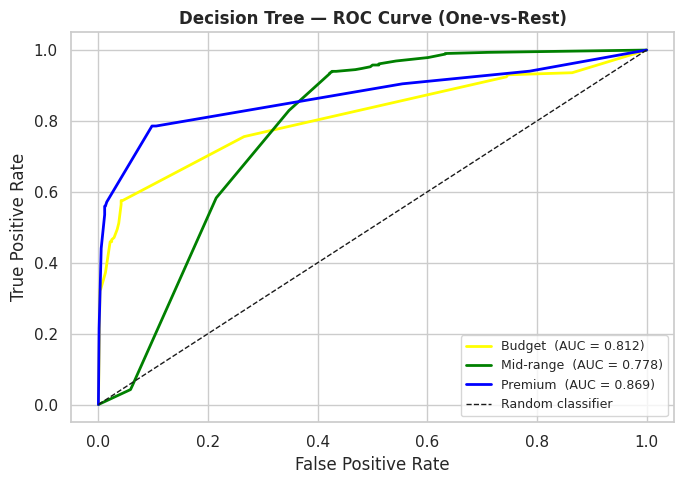

DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)

In [ ]:
dt_clf = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=RANDOM_STATE)

evaluate_classifier(
    dt_clf,
    X_tr_c_p, y_tr_c,
    X_te_c_p, y_te_c,
    name='Decision Tree'
)

**Insight**

* The above confusion matrix displays that manjority prediction lie on the diagonal line, implying the model accurately labels many cars but a few confusion occurs among nearby tiers( mid range vs premium)
* This normalised confusion matrix shows which groups have greater recall usually showing  that a single tier is predicted more correctly than the others
* ROC curve shows how clearly evry tier is divided such that curves nearer to the top left indicate stronger classification perfomance
* Any lower AUC or flatter ROC indicates weaker tier separation implying the model has difficulty to seperate specific price tiers

**MODEL 2: RANDOM FOREST**

The code trains a random forest refressor using preprocessed training data asessesit on the validation and test sets provides perfomance matrics

**Purpose**

* Train a esemble model
* Calculate and measure performance


  REGRESSOR: Random Forest
──────────────────────────────────────────────────────────
  Validation  MAE: EUR    2,303  RMSE: EUR    3,584  R2: 0.7644
  Test        MAE: EUR    2,360  RMSE: EUR    3,365  R2: 0.7728


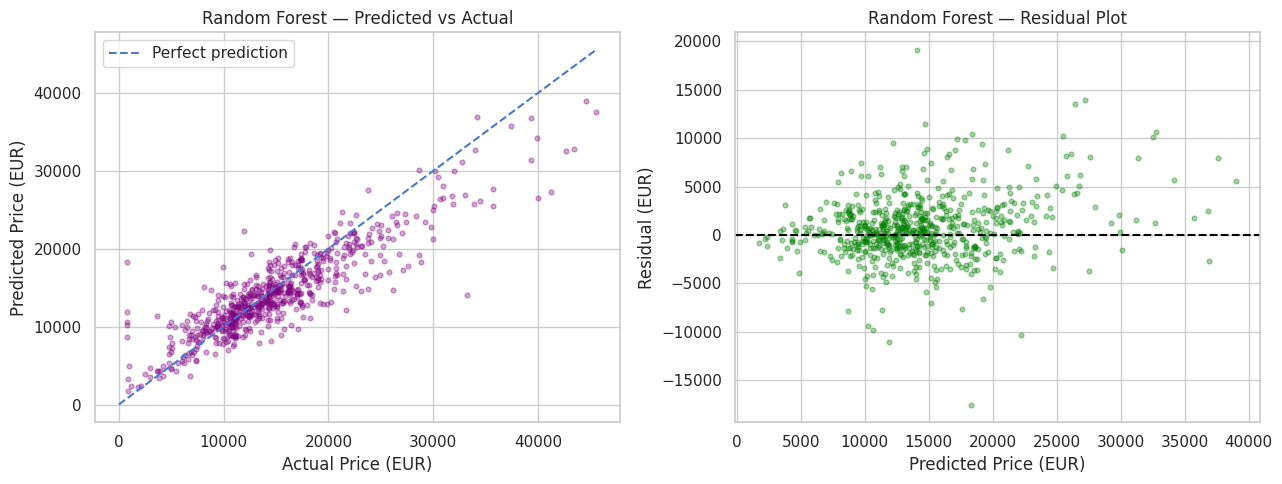

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=5,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
)

rf_fitted, rf_r2, rf_mae, rf_rmse = evaluate_regressor(
    rf_reg,
    X_train_p, y_train,
    X_val_p,   y_val,
    X_test_p,  y_test,
    name='Random Forest'
)

**Insights**
* Prediction accuracy: This models R2, RMSE and MAE scores show how accurately it estimates BMW price on validation and tset sets
* Error Distribution: Residual graph display if errors are ramdomly spread or if specific price ranges are over or underpredicted
* Generalisation Ability: Comparing validation and tset metrics shows if model overfits training data or else generalise well to unknown data

**CONFUSION MATRIX AND ROC CURVE FOR RANDOM FOREST**


  CLASSIFIER: Random Forest
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Budget       0.90      0.55      0.68       172
   Mid-range       0.85      0.98      0.91       616
     Premium       0.90      0.63      0.74        84

    accuracy                           0.86       872
   macro avg       0.88      0.72      0.78       872
weighted avg       0.86      0.86      0.85       872



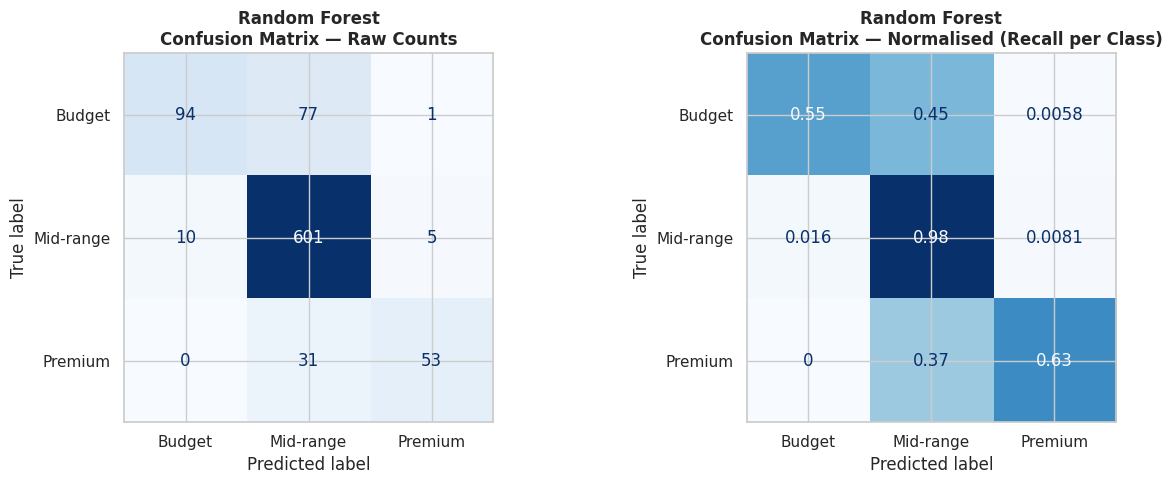

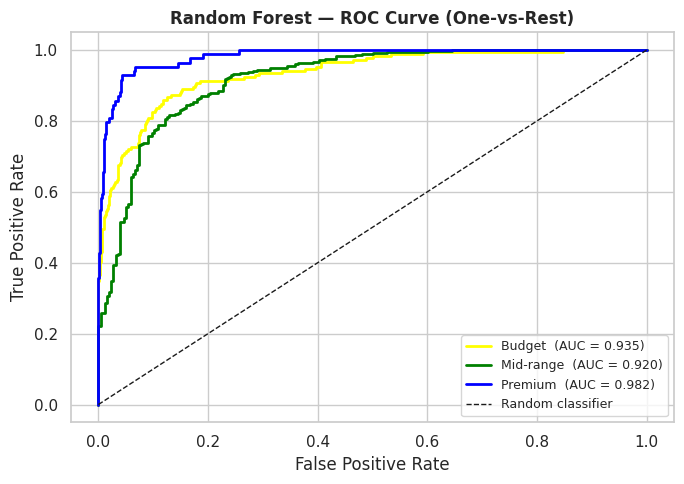

RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1
)

evaluate_classifier(
    rf_clf,
    X_tr_c_p, y_tr_c,
    X_te_c_p, y_te_c,
    name='Random Forest'
)

**Insights**

* Class Prediction accuracy: The confusion matrix chart shows that price tier are estimated correctly usually mid range
* Class recall and misclassificationn: the normalised matrix shows tiers which are often misclassified  
* ROC Performance: ROC Curves display how effectively every tier is divided , greater AUC indicates better results
* Model reliability across tiers: Flatter ROC curve shows less seperation as well as areas toimprovements

**MODEL 3: GRADIENT BOOSTING**

This trains gradient boosting regressor on preprocessed training data as well as measures its perfomance using validation and test sets.

This model sequentially buildss trees to fix earlier errors enhancing predictive accuarcy

**Pupose**
* decrease bias by iteratively enhancing prediction using training data
* Achieve greater accuracy than one tree models such as decision tree or random forest
* Manage complex relationships along with feature interaction inside tabular data efficiently


  REGRESSOR: Gradient Boosting
──────────────────────────────────────────────────────────
  Validation  MAE: EUR    2,182  RMSE: EUR    3,195  R2: 0.8126
  Test        MAE: EUR    2,174  RMSE: EUR    3,103  R2: 0.8068


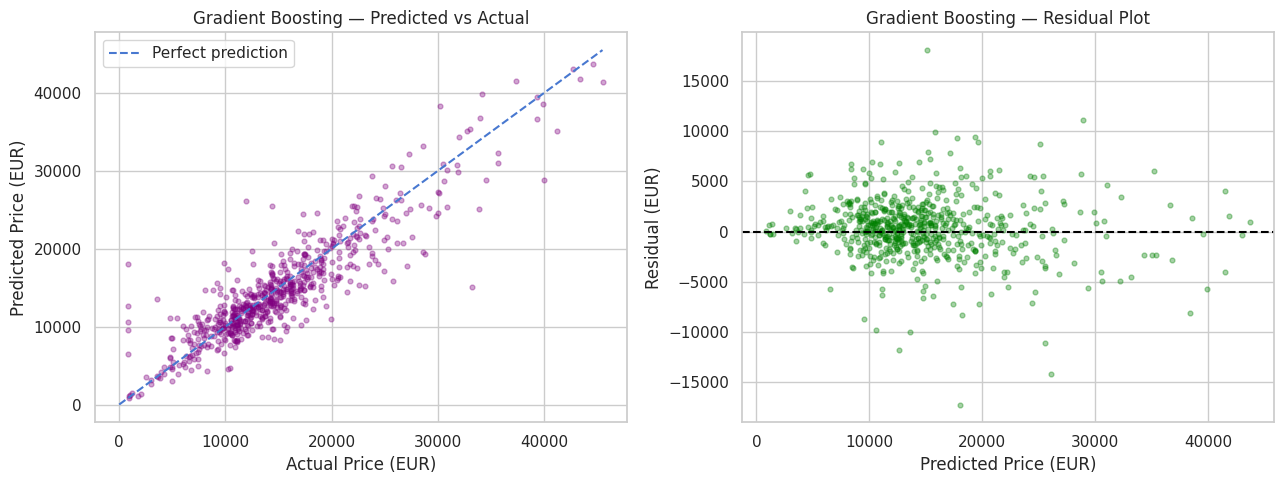

In [ ]:
gb_reg = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=RANDOM_STATE
)

gb_fitted, gb_r2, gb_mae, gb_rmse = evaluate_regressor(
    gb_reg,
    X_train_p, y_train,
    X_val_p,   y_val,
    X_test_p,  y_test,
    name='Gradient Boosting'
)

**Insights**
* High Prediction Accuracy : Gradient boosting estimates BMW cost precisely with higher R2 and lesser MAE/RMSE
* Error Patterns : Residual graph display errors which are mainly random along with some systematic wrong prediction
* Improved Generalizations : Validation and test metrics show strong generalisation and minimal overfittting
* Sequential Improvements : sequential decision trees lower bias and capture complicated variable interaction

**CONFUSION MATRIX AND ROC CURVE FOR GRADIENT BOOSTING**


  CLASSIFIER: Gradient Boosting
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Budget       0.85      0.65      0.74       172
   Mid-range       0.88      0.95      0.92       616
     Premium       0.86      0.77      0.81        84

    accuracy                           0.88       872
   macro avg       0.86      0.79      0.82       872
weighted avg       0.87      0.88      0.87       872



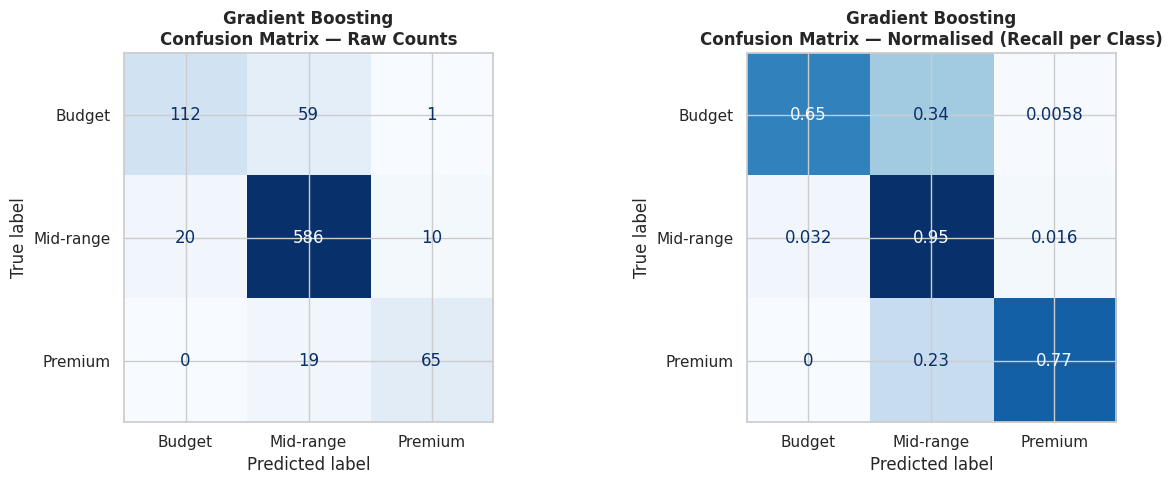

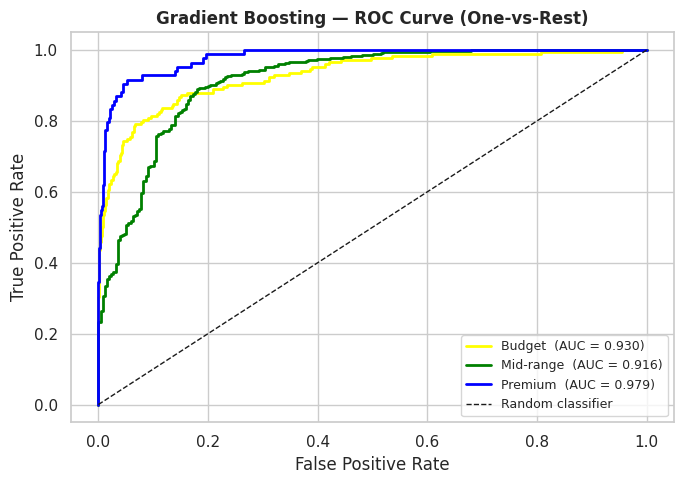

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42, subsample=0.8)

In [ ]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=RANDOM_STATE
)

evaluate_classifier(
    gb_clf,
    X_tr_c_p, y_tr_c,
    X_te_c_p, y_te_c,
    name='Gradient Boosting'
)

**Insights**

* Confusion matrix indicates that which price tiers are estimated precisely , usually mid range cars are more properly categorised
* Normalised confusion matrix shows tiers which are often wrongly classified and requireadditional focus
* ROC curve indicates how effectively all the class is divided larger AUC , indicates better prediction
* class seperation problems, flatter ROC curvepoints to classes in which model finds it ahrd to seprate tiers

**MODEL COMPARISION**

Model Comparison — Test Set Performance:
                   MAE (EUR)  RMSE (EUR)   R2
Gradient Boosting   2,174.32    3,103.08 0.81
Random Forest       2,359.95    3,364.73 0.77
Decision Tree       2,880.17    4,089.81 0.66


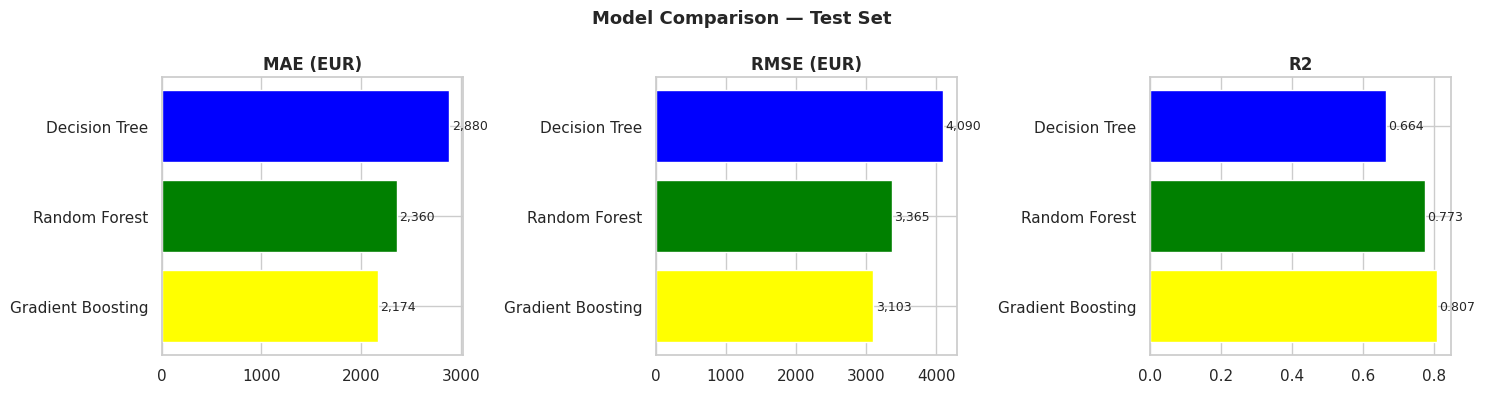


Best model: Gradient Boosting


In [ ]:
comparison = {
    'Decision Tree':     {'MAE (EUR)': dt_mae,  'RMSE (EUR)': dt_rmse,  'R2': dt_r2},
    'Random Forest':     {'MAE (EUR)': rf_mae,  'RMSE (EUR)': rf_rmse,  'R2': rf_r2},
    'Gradient Boosting': {'MAE (EUR)': gb_mae,  'RMSE (EUR)': gb_rmse,  'R2': gb_r2},
}
comp_df = pd.DataFrame(comparison).T.sort_values('RMSE (EUR)')

print('Model Comparison — Test Set Performance:')
print(comp_df.to_string(float_format=lambda x: f'{x:,.2f}'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = ['yellow', 'green', 'blue']

for ax, (metric, asc) in zip(axes, [('MAE (EUR)', True), ('RMSE (EUR)', True), ('R2', False)]):
    data = comp_df[metric].sort_values(ascending=asc)
    bars = ax.barh(data.index, data.values, color=palette)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}' if metric != 'R2' else f'{val:.3f}',
                va='center', fontsize=9)

plt.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_name = comp_df['RMSE (EUR)'].idxmin()
print(f'\nBest model: {best_name}')

**Key Insights**

* Gradient Boosting performs the best generally it has the lower RMSE and MAE , the highest R2indicating it predicts the prices most precisely
* Random Forest is comparabe it is slightly poorer compared to Gradient Bossting however cosiderably better then decision tree baseline
* Decision Tree is weakest as larger errors and lower R2 shows ovrfitting or less predictive power
* Clear metric comparision: Visualizations makes it easier to observe variations between each models and metrics enabling select the best model for implementation


**HYPERPARAMETER TUNING**

**Tuning For Random Forest**

The following code uses GridSearchCV to tune Random forest by assessing various parameter combinations as well as choosing the ine with lower RMSE enabling enhance accuracy. This is used here to automatically idendify the best parameters rather manually testing different values guaranting the model performs efficiently

In [ ]:
param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 0.5],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
gs_rf.fit(X_tv_p, y_tv_comb)
print(f'Best RF params:  {gs_rf.best_params_}')
print(f'Best RF CV RMSE: {-gs_rf.best_score_:.5f}')

Best RF params:  {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV RMSE: 0.30778


**Tuning for Gradient Boosting**

This code use GridSearchCV to optimise the GradientBoosting model by analysing various configurations and choosing which achives the best cross validated accuracy


In [ ]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0],
}

gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_gb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
gs_gb.fit(X_tv_p, y_tv_comb)
print(f'Best GB params:  {gs_gb.best_params_}')
print(f'Best GB CV RMSE: {-gs_gb.best_score_:.5f}')

Best GB params:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best GB CV RMSE: 0.30544


**SELECTING BEST TUNED MODEL**

* The following code evaluates the perfomance of both Random Forest as well as Gradient Boosting models and chooses the one which gave lower RMSE score
* This also guarantees the best perfoming tuned model is selected automaticaly for the final use

In [ ]:
if -gs_rf.best_score_ <= -gs_gb.best_score_:
    best_tuned  = gs_rf.best_estimator_
    best_tuned_name = 'Random Forest (Tuned)'
else:
    best_tuned  = gs_gb.best_estimator_
    best_tuned_name = 'Gradient Boosting (Tuned)'

print(f'\nBest tuned model: {best_tuned_name}')


Best tuned model: Gradient Boosting (Tuned)


**FINAL MODEL EVALUATION ON HELD OUT TEST DATA**

The test is reserved completely all through the enrire modelling process this is applied only once in this step to get a fair unbiased estimate of how the final model will perform on the actually heldout data in the implementation using test set privously to direct model selection could bias itand generate overly opstimstic predictions

**Metrics**

* **MAE:** Mean absolute prediction eorror in EUR which is directly understandable
* **RMSE:** Penalizes major error more strongly which is crucial whenever ecostly errors must be avoided

* **R2:** Fraction of the cost variance captured through the model R2=1 is ideal and R2=0 indicates model is no better then estimating the mean



In [ ]:
best_tuned.fit(X_tv_p, y_tv_comb)

y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(best_tuned.predict(X_test_p))

final_mae  = mean_absolute_error(y_test_euro, y_pred_euro)
final_rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
final_r2   = r2_score(y_test_euro, y_pred_euro)

print('=' * 50)
print(f'  FINAL TEST SET — {best_tuned_name}')
print('=' * 50)
print(f'  MAE  : EUR {final_mae:>10,.2f}')
print(f'  RMSE : EUR {final_rmse:>10,.2f}')
print(f'  R2   : {final_r2:>16.4f}')
print('=' * 50)

  FINAL TEST SET — Gradient Boosting (Tuned)
  MAE  : EUR   2,151.31
  RMSE : EUR   3,069.05
  R2   :           0.8110


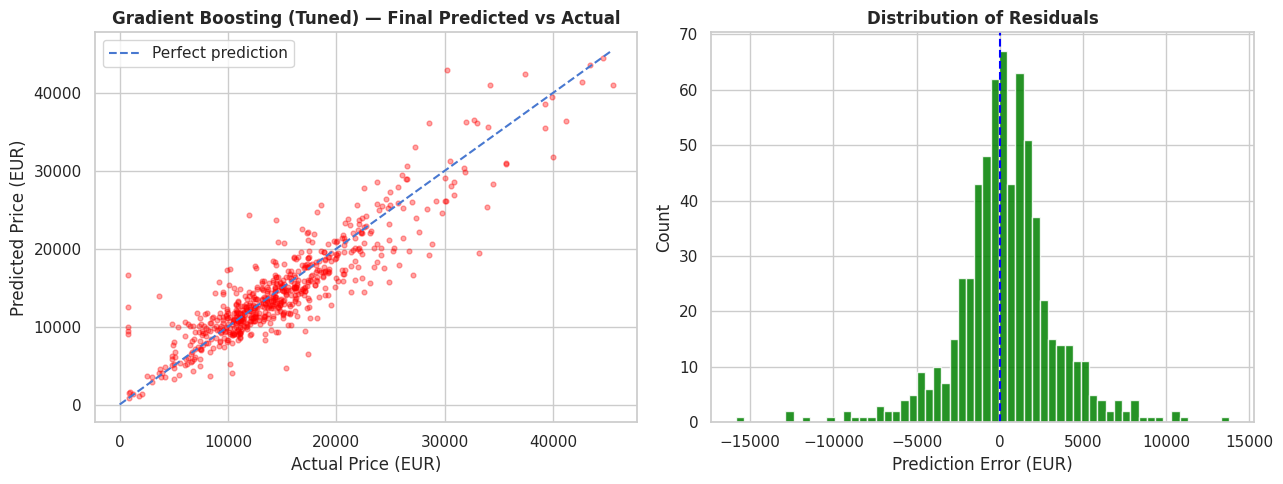

Prediction accuracy thresholds:
  Within +/- EUR   500: 19.7% of predictions
  Within +/- EUR 1,000: 33.5% of predictions
  Within +/- EUR 2,000: 62.5% of predictions
  Within +/- EUR 5,000: 90.5% of predictions


In [ ]:
residuals = y_test_euro - y_pred_euro

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mx = max(y_test_euro.max(), y_pred_euro.max())
axes[0].scatter(y_test_euro, y_pred_euro, alpha=0.35, s=12, color='red')
axes[0].plot([0, mx], [0, mx], 'b--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (EUR)')
axes[0].set_ylabel('Predicted Price (EUR)')
axes[0].set_title(f'{best_tuned_name} — Final Predicted vs Actual', fontweight='bold')
axes[0].legend()

axes[1].hist(residuals, bins=60, color='green', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='blue', ls='--', lw=1.5)
axes[1].set_xlabel('Prediction Error (EUR)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals', fontweight='bold')

plt.tight_layout()
plt.show()

print('Prediction accuracy thresholds:')
for t in [500, 1000, 2000, 5000]:
    pct = (np.abs(residuals) <= t).mean() * 100
    print(f'  Within +/- EUR {t:>5,}: {pct:.1f}% of predictions')

**Insights**

* Prediction Perfomance: the above scatter plot displays how tightly predicted values align actual value and residual plot emphasizes that w most prediction errors are minor  as well as focused around zero
* Accuracy Threshold: The large proportion of the prediction lie within acceptable eorror margins showing the model is accurately estimating carprices.

**FINAL DISCUSSION**


**Strength of the pipeline**

* **End to End workflow**  The pipeline includes all the neccessary steps data exploration, preprocessing, model training, hyprparameter tuinng and evaluation

* **Three Model compared:** Decision tree, Random forest and Gradient boosting were collectively trained and assessed allowing a fair data driven comparision over an interpretable model, a variance reducing model and bias reducing sequencial esembel
* **Train-Validation-Test split:** data was split into 3 seperate subsets prior any preprocessing ensuring no data leakage at any phase
* **Significant Evaluation:** Models were compared using MAE,RMSE and R2 all together providing a overall summary of both average error mgnitude as well as explanatory power. Confusion matrix and ROc were presented in the classification variant
* **Hyperparameter Tuining:** I have used GridSearchCV with 5 fold cross validation  to methodically search for the best combination of hyperparameter


**Limitations**

* **Dataset Specificiity:** The dataset is from french market plce therefore pricing trends may change and the model might require regular retraining
* **Key features miissing:** significant real world factors like accident history, servise record as well as add ons are missing will limit the model accuracy
* **Decision Tree overfitting:** It can overfit the training data tuining maxmium depth helps yet this reamins as the weakest  model
* **Gradient boosting value:** It provides the hight accuracy but takes longer to fit and requires carefull tuining, making fast retrainig harder

**Major informative Features**

* Engine power - Primary predictor, greater power typically increases the price
* Mileage - Greater mileage steadly decreases the cost
* Cars age -  Aged vehicles are cheaper because of value loss
* Mileager per year - this indicates the intesity with thecar was driven beyond overall mileage
* Fuel type - Diesel vehiles typically cost more


**CONCLUSION**

 In this project i have developed a comprehensive ML pipelien in order to pridict the price of used BMW cars. This includes data loading null injection and cleaning, EDA, feature engineering and preprocessing. i have implemented three models such as Decision Tree, Random Forest and GradientBoosting

 Considering the evaluation

 * Gradient Boosting achieved the highest performance with lower RMSE and highest R2 managing the dataset's non linear cost trends efficiently
 * Random forest was nearly matched Gradient boosting in accuracy, fitted more quickly and gave consistent variable importance highlighting engine power, mileage and age as dominant factors
 * Decision Tree was very weak compared to the other models in terms of the accuracy it was not able to capture complicated pricings without overfitting showing the requirement of esemble methods

 **FINAL MODEL**

I would select Gradient Boosting for deployment because it gave best accuracy and generalisation on held on data as well as hyperparameter tuining by GridSearchCV which additionally improved its perfomance.


